In [203]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, r2_score, root_mean_squared_error
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
dataset = pd.read_csv('/content/train.csv')

In [4]:
dataset.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000,72796.000000
mean,36397.500000,20.544192,4.008931,71.997143,7.073284,62.531184
std,21014.539435,2.256859,2.360688,17.461785,1.744255,18.941811
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,18198.750000,19.000000,1.980000,56.900000,5.600000,48.800000
50%,36397.500000,21.000000,4.010000,72.700000,7.100000,62.700000
75%,54596.250000,23.000000,6.060000,87.300000,8.600000,76.300000
max,72795.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72796 entries, 0 to 72795
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                72796 non-null  int64  
 1   age               72796 non-null  int64  
 2   gender            72796 non-null  object 
 3   course            72796 non-null  object 
 4   study_hours       72796 non-null  float64
 5   class_attendance  72796 non-null  float64
 6   internet_access   72796 non-null  object 
 7   sleep_hours       72796 non-null  float64
 8   sleep_quality     72796 non-null  object 
 9   study_method      72796 non-null  object 
 10  facility_rating   72796 non-null  object 
 11  exam_difficulty   72796 non-null  object 
 12  exam_score        72796 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 7.2+ MB


In [6]:
dataset.shape

(72796, 13)

In [7]:
dataset.isna().sum()

,0
id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [8]:
dataset.sample(10)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
52127,52127,19,other,b.sc,5.25,72.5,yes,9.9,good,online videos,high,hard,88.0
7950,7950,23,female,b.com,0.38,78.4,yes,9.9,good,self-study,low,moderate,30.8
30053,30053,17,other,bca,6.55,47.3,yes,5.6,average,group study,low,moderate,64.0
71035,71035,17,female,b.sc,2.91,47.4,yes,5.3,poor,coaching,high,easy,69.0
71459,71459,22,other,bba,7.52,73.6,yes,6.5,good,mixed,low,hard,92.5
67701,67701,19,male,b.com,3.08,79.0,yes,7.9,good,mixed,high,moderate,62.9
31671,31671,24,male,bba,2.37,52.1,yes,8.6,poor,mixed,low,moderate,29.0
26949,26949,21,male,b.com,1.00,64.5,yes,4.2,average,group study,high,moderate,44.5
37936,37936,18,female,diploma,4.35,72.7,yes,7.4,good,group study,low,moderate,64.8
56827,56827,24,male,b.com,0.18,89.4,yes,8.9,poor,group study,high,moderate,42.1


<Axes: ylabel='count'>

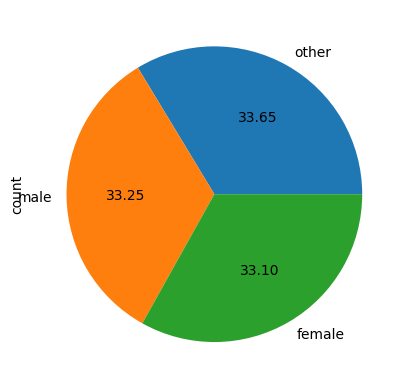

In [15]:
dataset['gender'].value_counts().plot(kind = 'pie', autopct = '%.2f')

<Axes: xlabel='gender', ylabel='count'>

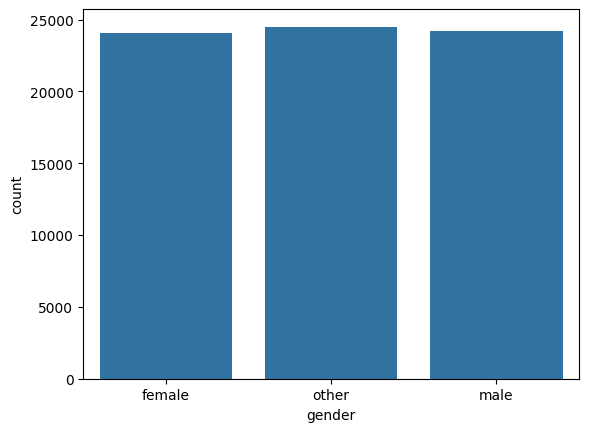

In [14]:
sns.countplot(dataset, x = 'gender')

<Axes: ylabel='count'>

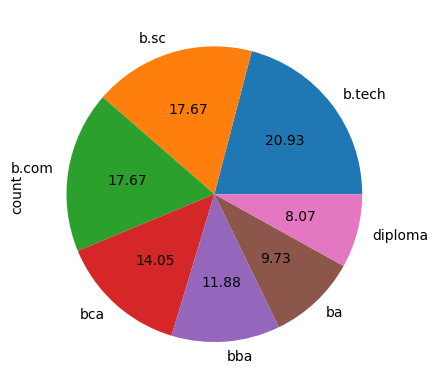

In [16]:
dataset['course'].value_counts().plot(kind = 'pie', autopct = '%.2f')

<Axes: xlabel='course', ylabel='count'>

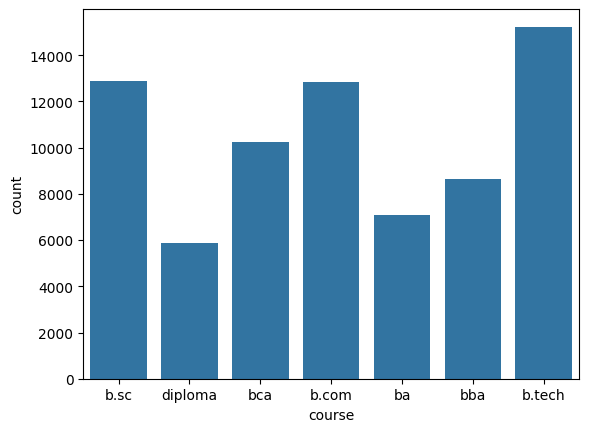

In [19]:
sns.countplot(x = dataset.course)

<Axes: ylabel='count'>

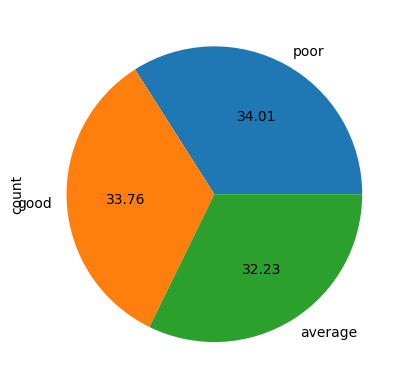

In [20]:
dataset['sleep_quality'].value_counts().plot(kind = 'pie', autopct = '%.2f')

<Axes: ylabel='count'>

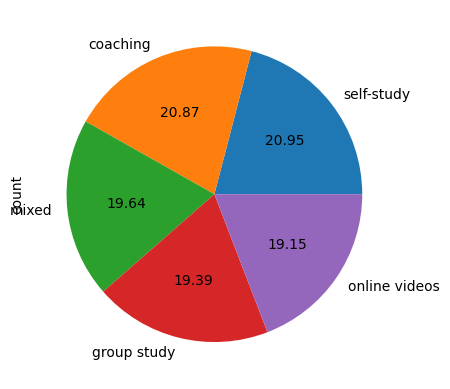

In [21]:
dataset['study_method'].value_counts().plot(kind = 'pie', autopct = '%.2f')

<Axes: ylabel='count'>

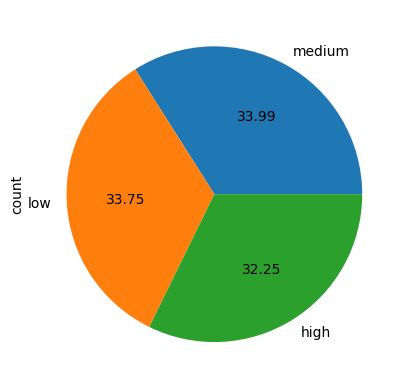

In [22]:
dataset['facility_rating'].value_counts().plot(kind = 'pie', autopct = '%.2f')

<Axes: ylabel='count'>

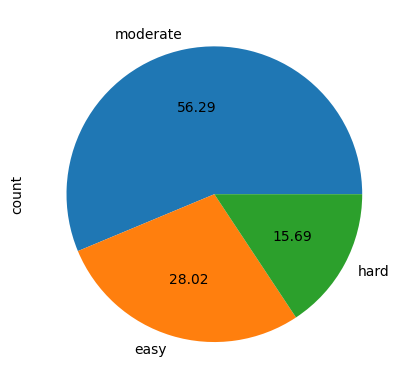

In [23]:
dataset['exam_difficulty'].value_counts().plot(kind = 'pie', autopct = '%.2f')

In [24]:
dataset.sample(10)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
10660,10660,23,male,ba,7.24,81.6,yes,6.4,average,coaching,medium,moderate,88.7
67861,67861,24,male,b.tech,2.17,68.7,yes,9.2,average,self-study,medium,moderate,50.6
28414,28414,17,male,b.tech,6.02,60.9,yes,8.9,good,mixed,medium,moderate,78.8
26122,26122,21,female,ba,4.82,55.0,yes,5.7,poor,group study,medium,moderate,55.7
23600,23600,23,female,diploma,2.81,91.1,yes,9.5,poor,mixed,low,hard,74.5
15044,15044,24,male,b.sc,0.08,81.9,yes,5.1,good,self-study,low,moderate,28.6
49070,49070,21,other,ba,3.59,75.8,yes,8.1,poor,coaching,medium,easy,59.6
24267,24267,21,other,b.sc,5.15,72.9,yes,7.9,average,mixed,medium,easy,90.4
66059,66059,24,female,bca,3.03,65.6,yes,5.5,good,coaching,low,moderate,55.7
70172,70172,23,female,b.tech,0.19,73.3,no,8.1,poor,self-study,medium,easy,49.4


In [25]:
dataset.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [140]:
y = dataset.exam_score

In [141]:
dataset.drop('exam_score', axis = 1, inplace = True)

In [167]:
one_hot_cols = ['gender', 'course', 'study_method', 'internet_access']
ordinal_cols = ['sleep_quality', 'facility_rating', 'exam_difficulty']

sleep_order = ['poor', 'average', 'good'] # Check your unique values for these!
facility_order = ['low', 'medium', 'high']
difficulty_order = ['easy', 'moderate', 'hard']

In [168]:
dataset.drop('id', inplace = True, axis =1)

KeyError: "['id'] not found in axis"

In [169]:
ct = ColumnTransformer(transformers = [
    ('one_hot', OneHotEncoder(drop = 'if_binary'), one_hot_cols),
    ('ordinal', OrdinalEncoder(categories = [sleep_order, facility_order, difficulty_order]), ordinal_cols)
], remainder = 'passthrough')

In [170]:
encoded_array = ct.fit_transform(dataset)
raw_names = ct.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_names]

In [171]:
new_dataset = pd.DataFrame(encoded_array, columns = cols)

<Axes: >

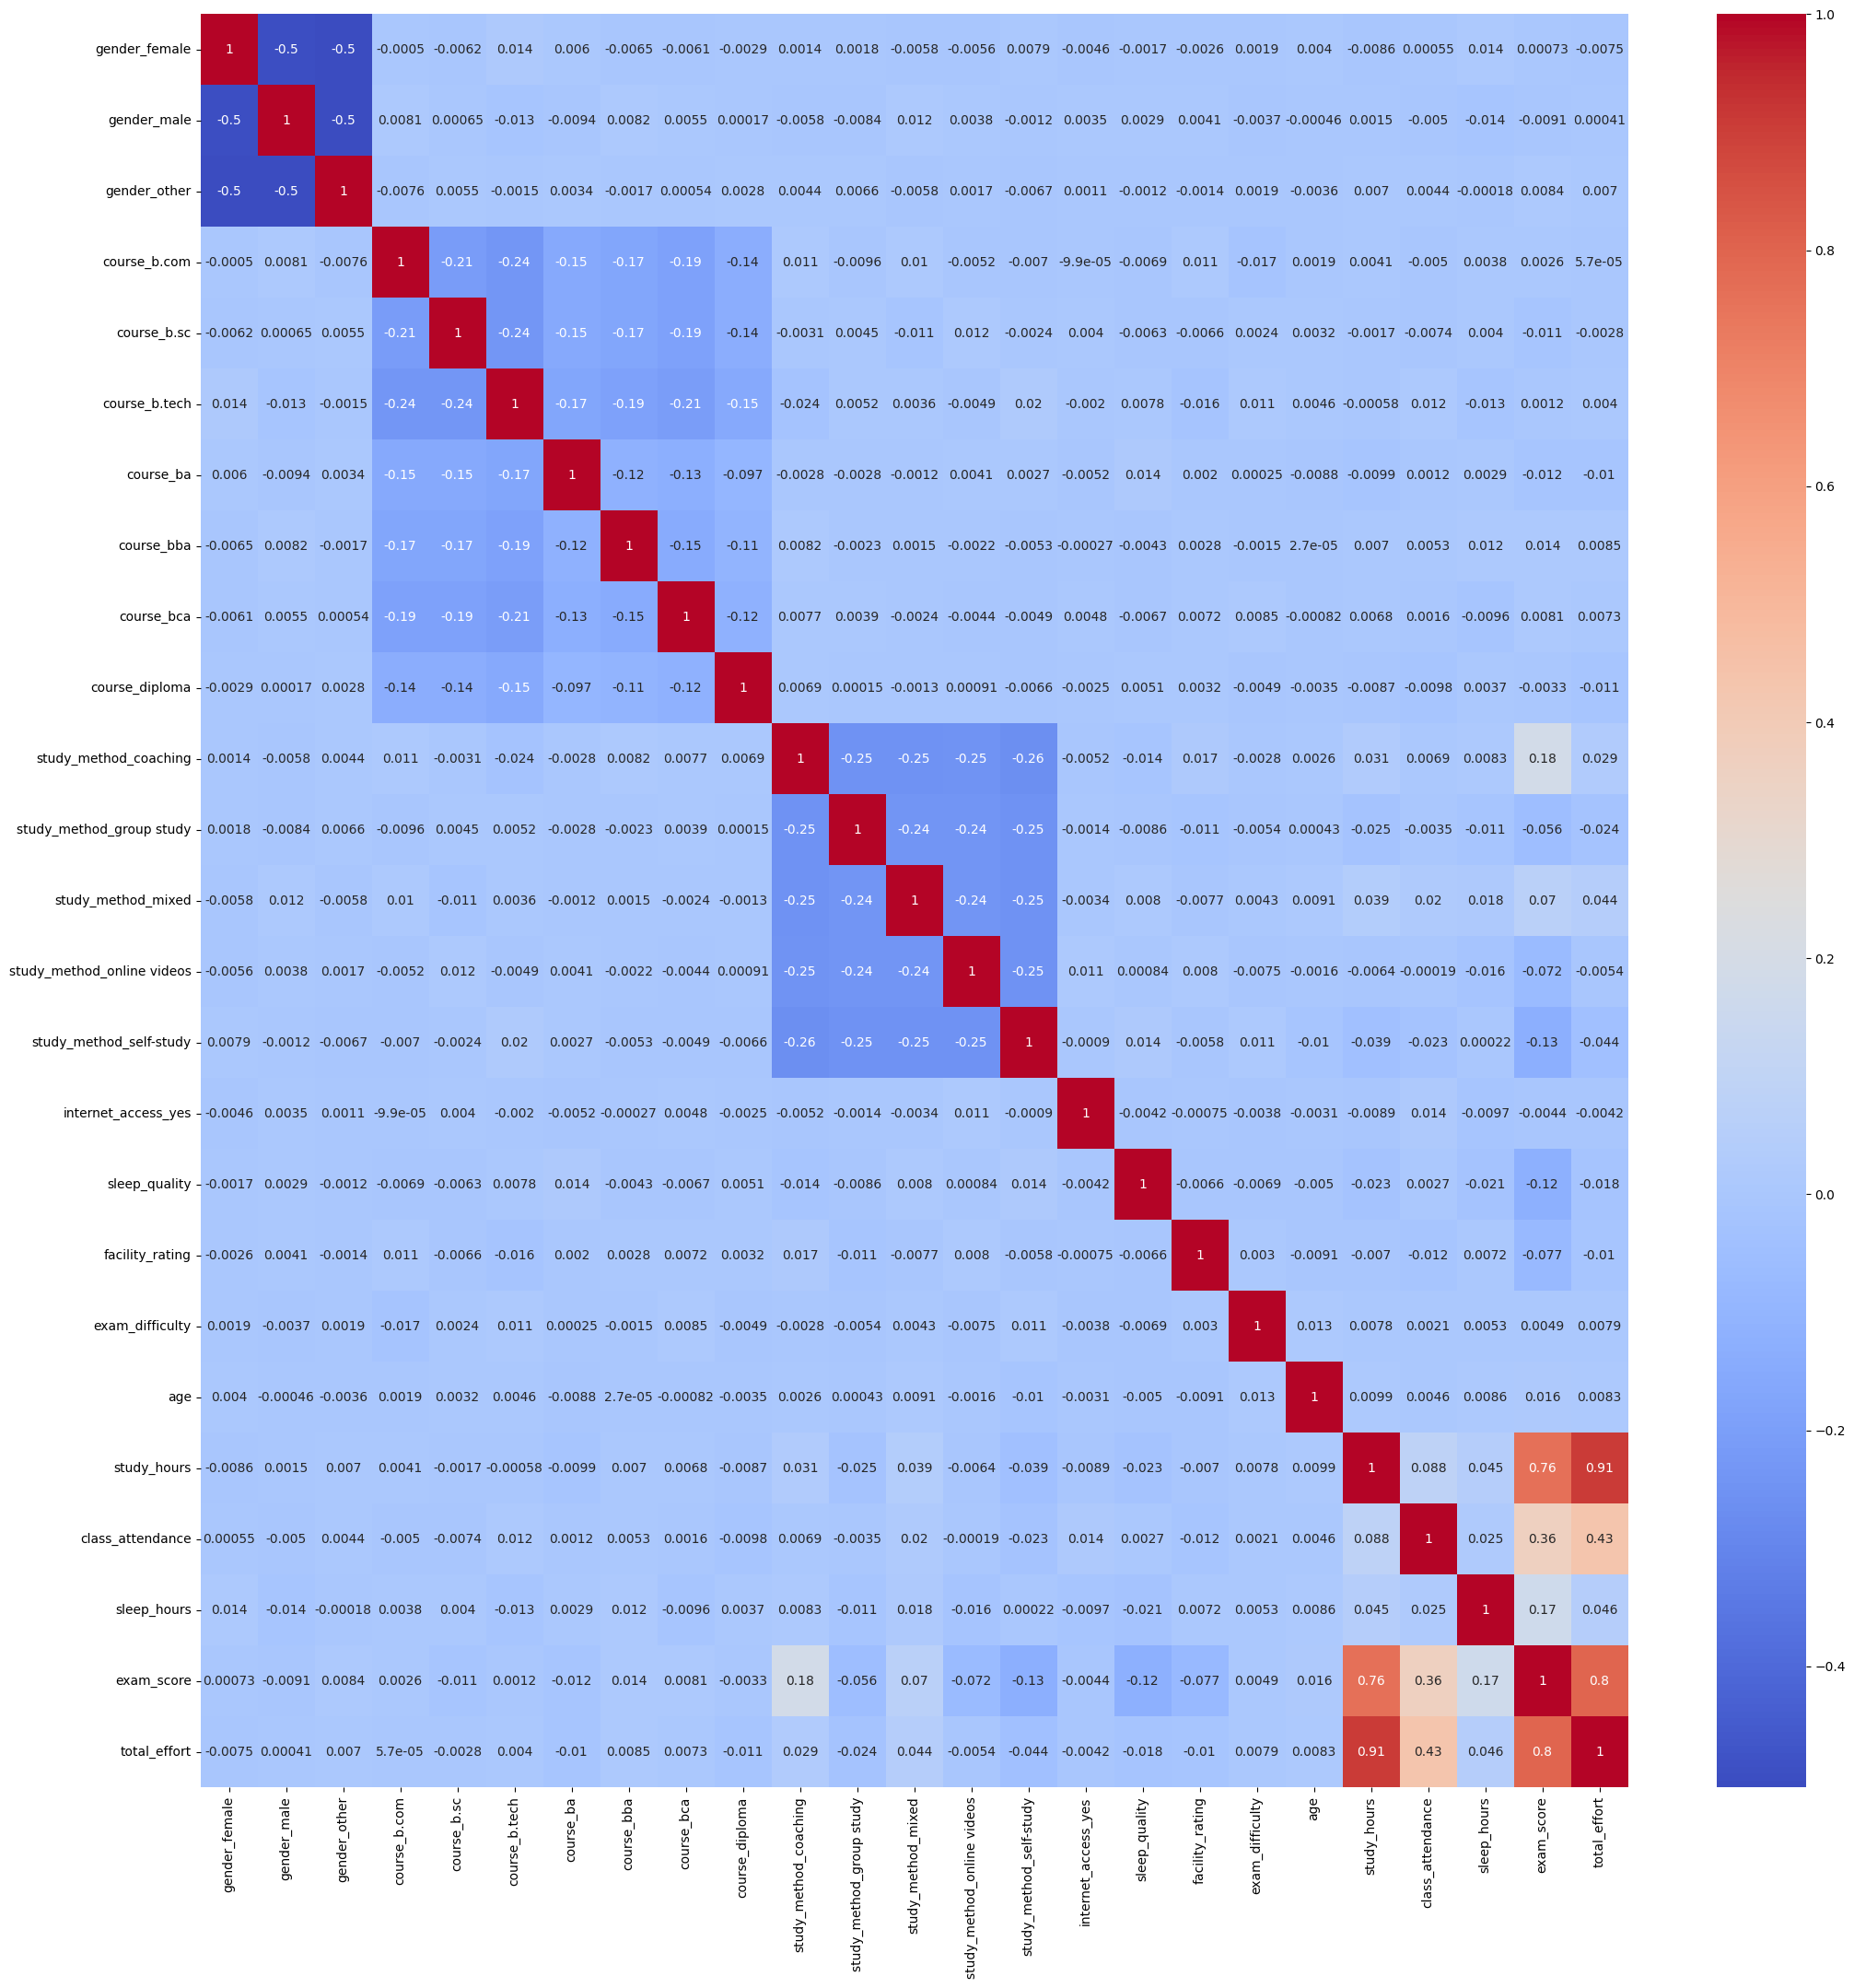

In [65]:
fig, ax = plt.subplots(figsize =(25,25))
sns.heatmap(diff_dataset.corr(), annot = True, cbar = True, cmap = 'coolwarm')

In [46]:
new_dataset

,gender_female,gender_male,gender_other,course_b.com,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,...,study_method_self-study,internet_access_yes,sleep_quality,facility_rating,exam_difficulty,age,study_hours,class_attendance,sleep_hours,exam_score
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,21.0,7.91,98.8,4.9,78.3
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,2.0,2.0,2.0,18.0,4.95,94.8,4.7,46.7
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,0.0,2.0,20.0,4.68,92.6,5.8,99.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,2.0,19.0,2.00,49.5,8.3,63.9
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,0.0,0.0,23.0,7.65,86.9,9.6,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72791,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,17.0,3.56,69.7,4.1,36.8
72792,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,2.0,1.0,2.0,24.0,1.68,86.9,4.1,47.7
72793,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,22.0,0.66,82.6,7.7,37.0
72794,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,1.0,1.0,19.0,6.83,99.4,9.0,79.2


In [172]:
diff_dataset = new_dataset

In [173]:
diff_dataset['total_effort'] = diff_dataset['class_attendance'] * diff_dataset['study_hours']

In [176]:
x = diff_dataset

In [177]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 43)

In [178]:
models = [
    ('linearReg', LinearRegression()),
    ('DecisionTree', DecisionTreeRegressor()),
    ('randomforest', RandomForestRegressor(n_estimators=50)),
    ('xgboost', XGBRegressor()),
    ('gradientboost', GradientBoostingRegressor(n_estimators=50, learning_rate=0.08)),
]

In [52]:
results = []
kf = KFold(shuffle = True, n_splits = 10, random_state = 43)

for name, model in models:
  training_model = Pipeline(steps=[
      ('scalar', StandardScaler()),
      (name, model)
  ])

  scores = cross_val_score(training_model, x, y, cv = kf, scoring = 'neg_root_mean_squared_error');

  results.append({
      'Model_Name' : name,
      'Mean_accuracy' : scores.mean(),
      'std dev': scores.std()
  })

result_df = pd.DataFrame(results)

In [56]:
result_df

,Model_Name,Mean_accuracy,std dev
0,linearReg,-9.780353,0.038293
1,DecisionTree,-12.997636,0.110862
2,randomforest,-9.269498,0.043489
3,xgboost,-8.968775,0.038520
4,gradientboost,-9.419874,0.040465


In [179]:
mymodel = XGBRegressor(n_estimators=300, learning_rate = 0.1, max_depth = 4)
mymodel.fit(x, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [186]:
ypreds = mymodel.predict(xtest)
accuracy = root_mean_squared_error(ypreds, ytest)

In [125]:
print(accuracy)

8.800752623637761


In [180]:
model2 = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42
)

In [181]:
model2.fit(x, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 72796, number of used features: 24
[LightGBM] [Info] Start training from score 62.531184


LGBMRegressor(learning_rate=0.05, max_depth=7, n_estimators=300,
              random_state=42)

In [187]:
preds2 = model2.predict(xtest)


In [188]:
final_preds = preds2*0.5 + ypreds*0.5

In [189]:
root_mean_squared_error(final_preds, ytest)

8.502551091962797

In [204]:
model3 = CatBoostRegressor(
    iterations=1000,          # Like n_estimators
    learning_rate=0.05,
    depth=6,                  # Like max_depth
    l2_leaf_reg=3,            # Regularization (stops overfitting)
    loss_function='RMSE',
    verbose=100               # Prints progress every 100 trees
)

In [ ]:
model3.fit(x, y)

0:	learn: 18.2992965	total: 108ms	remaining: 1m 47s
100:	learn: 8.8691786	total: 2.97s	remaining: 26.5s
200:	learn: 8.7876886	total: 5.25s	remaining: 20.9s
300:	learn: 8.7408968	total: 8.98s	remaining: 20.9s
400:	learn: 8.6989781	total: 12.1s	remaining: 18.1s
500:	learn: 8.6612838	total: 14.5s	remaining: 14.5s
600:	learn: 8.6256988	total: 17.6s	remaining: 11.7s
700:	learn: 8.5922506	total: 20.3s	remaining: 8.67s
800:	learn: 8.5592772	total: 24.1s	remaining: 5.99s
900:	learn: 8.5285879	total: 26.6s	remaining: 2.92s
999:	learn: 8.4982675	total: 27.9s	remaining: 0us


In [135]:
test = pd.read_csv('/content/test.csv')

In [136]:
id = test.id

In [137]:
test.drop('id', axis =1 , inplace = True)

In [138]:
test

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate
...,...,...,...,...,...,...,...,...,...,...,...
269995,21,other,b.com,2.55,82.3,yes,8.4,average,mixed,medium,hard
269996,17,female,b.com,0.49,46.4,yes,8.8,good,mixed,low,easy
269997,22,male,bba,6.62,74.7,yes,5.5,good,coaching,high,easy
269998,22,other,ba,4.08,51.8,yes,8.7,poor,online videos,high,moderate


In [190]:
encoded = ct.transform(test)
raw_names = ct.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_names]

In [191]:
test_dataset = pd.DataFrame(encoded, columns = cols)

In [192]:
test_dataset

,gender_female,gender_male,gender_other,course_b.com,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,...,study_method_online videos,study_method_self-study,internet_access_yes,sleep_quality,facility_rating,exam_difficulty,age,study_hours,class_attendance,sleep_hours
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,2.0,0.0,24.0,6.85,65.2,5.2
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,18.0,6.61,45.0,9.3
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2.0,1.0,1.0,24.0,6.60,98.5,6.2
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,24.0,3.03,66.3,5.7
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,20.0,2.03,42.4,9.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,2.0,21.0,2.55,82.3,8.4
269996,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2.0,0.0,0.0,17.0,0.49,46.4,8.8
269997,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,2.0,2.0,0.0,22.0,6.62,74.7,5.5
269998,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,2.0,1.0,22.0,4.08,51.8,8.7


In [193]:
test_dataset['total_effort'] = test_dataset['class_attendance'] * test_dataset['study_hours']

In [194]:
prediction1 = mymodel.predict(test_dataset)
prediction2 = model2.predict(test_dataset)

In [195]:
preds = prediction1*0.5 + prediction2*0.5

In [196]:
submission = pd.DataFrame({
    "id": id,
    "exam_score": preds
})

In [197]:
submission

,id,exam_score
0,630000,71.739111
1,630001,69.802125
2,630002,87.763077
3,630003,55.183844
4,630004,46.640843
...,...,...
269995,899995,58.970840
269996,899996,38.725827
269997,899997,91.654568
269998,899998,55.514721


In [201]:
submission.to_csv('submission.csv', index = False)

In [198]:
submission.shape

(270000, 2)